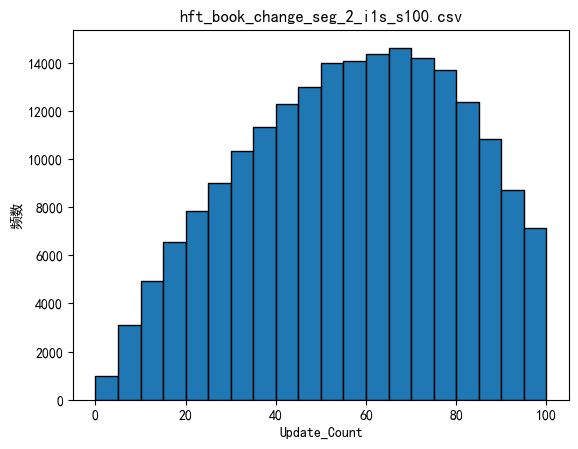

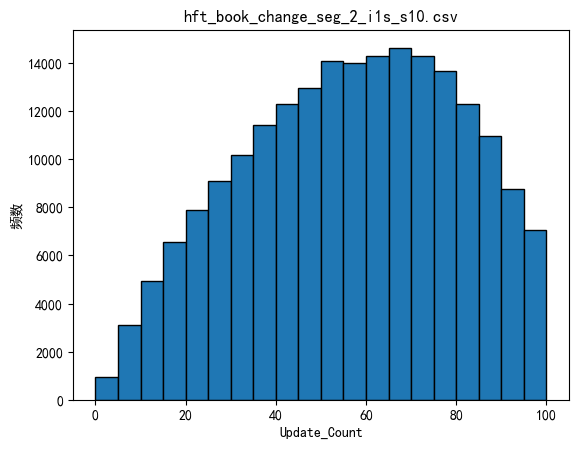

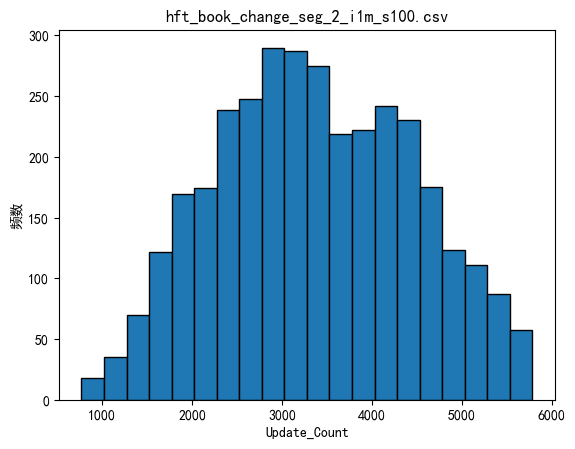

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_last_column_histogram(filepath):
    """
    读取一个CSV文件，并将最后一列绘制为直方图。

    Args:
        filepath (str): CSV文件的路径。
    """
    try:
        # 使用pandas读取CSV文件
        df = pd.read_csv(filepath)

        # 获取最后一列的列名
        last_column_name = df.columns[-1]

        # 提取最后一列的数据
        last_column_data = df[last_column_name]

        # 绘制直方图
        plt.hist(last_column_data, bins=20, edgecolor='black')

        # 添加标题和标签
        plt.title(f'{filepath}')
        plt.xlabel(last_column_name)
        plt.ylabel('频数')

        # 显示图形
        plt.show()

    except FileNotFoundError:
        print(f"错误：找不到文件 '{filepath}'")
    except Exception as e:
        print(f"发生错误： {e}")


plot_last_column_histogram("hft_book_change_seg_2_i1s_s100.csv")
plot_last_column_histogram("hft_book_change_seg_2_i1s_s10.csv")
plot_last_column_histogram("hft_book_change_seg_2_i1m_s100.csv")

数据加载完成，显示前5行：
Datetime
2025-03-03 14:56:00    4046
2025-03-03 14:57:00    5705
2025-03-03 14:58:00    5711
2025-03-03 14:59:00    5625
2025-03-03 15:00:00    5785
Name: Update_Count, dtype: int64
------------------------------
正在生成时间序列图...


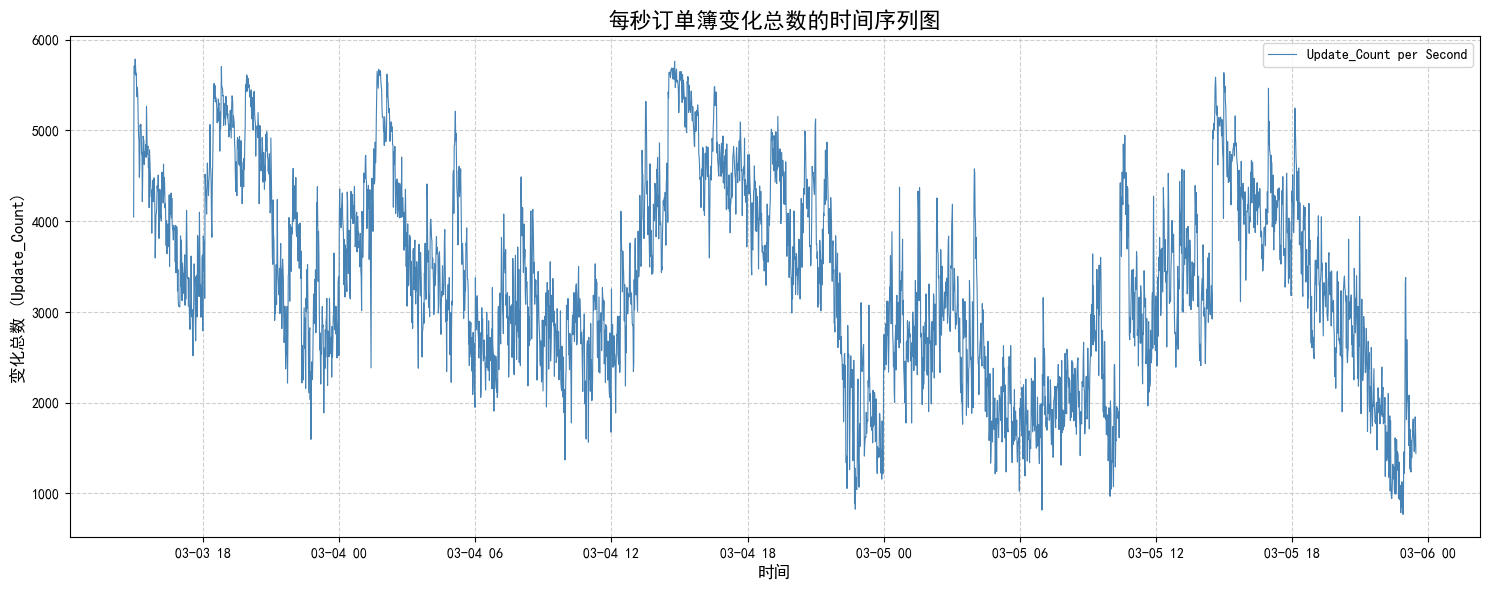

正在生成ACF图...


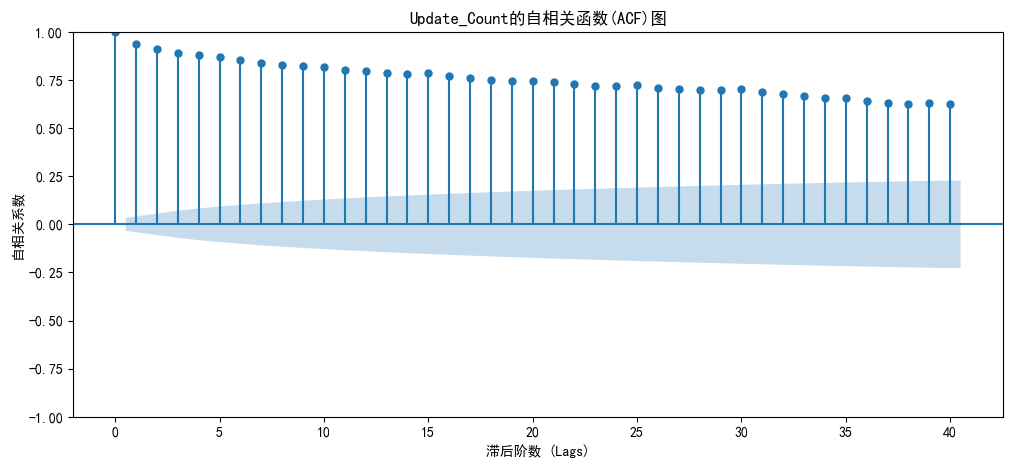

正在执行 Ljung-Box 检验...
Ljung-Box 检验结果:
         lb_stat  lb_pvalue
10  25454.733212        0.0

检验结论: p值 (0.0000) 小于 0.05，强烈表明该序列存在显著的自相关性，即存在波动性聚集现象。
------------------------------
正在拟合GARCH(1,1)模型...
GARCH(1,1) 模型拟合结果摘要:
                     Constant Mean - GARCH Model Results                      
Dep. Variable:           Update_Count   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -27715.4
Distribution:                  Normal   AIC:                           55438.9
Method:            Maximum Likelihood   BIC:                           55463.4
                                        No. Observations:                 3393
Date:                Fri, Jan 16 2026   Df Residuals:                     3392
Time:                        00:03:58   Df Model:                            1
                                 Mean Model                         

d:\Software\miniconda3\envs\CryptoSpider\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.186e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model
import warnings

# 忽略一些未来版本警告，使输出更整洁
warnings.filterwarnings('ignore', category=FutureWarning)

# --- 第0步：加载和准备数据 ---

# 从CSV文件加载数据
# 注意：请将 'my_data.csv' 替换为您自己的文件名
try:
    df = pd.read_csv('hft_book_change_seg_2_i1m_s100.csv')
except FileNotFoundError:
    print("错误：请确保您的CSV文件名正确，并且文件与脚本在同一目录下。")
    exit()

# 将 'Datetime' 列转换为Pandas的datetime对象，这是进行时间序列分析的关键
df['Datetime'] = pd.to_datetime(df['Datetime'])

# 将 'Datetime' 列设置为数据框的索引，方便按时间进行操作和绘图
df = df.set_index('Datetime')

# 选择我们关心的 'Update_Count' 列
update_counts = df['Update_Count']

print("数据加载完成，显示前5行：")
print(update_counts.head())
print("-" * 30)


# --- 第1步：可视化分析 ---
print("正在生成时间序列图...")
plt.figure(figsize=(15, 6))
plt.plot(update_counts.index, update_counts, label='Update_Count per Second', color='steelblue', linewidth=0.8)
plt.title('每秒订单簿变化总数的时间序列图', fontsize=16)
plt.xlabel('时间', fontsize=12)
plt.ylabel('变化总数 (Update_Count)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# --- 第2步：量化分析（自相关性） ---

# 2.1 绘制自相关函数（ACF）图
# 波动性聚集通常体现在数值大小的自相关上，所以我们直接对'Update_Count'进行分析
print("正在生成ACF图...")
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(update_counts, lags=40, ax=ax)
ax.set_title('Update_Count的自相关函数(ACF)图')
ax.set_xlabel('滞后阶数 (Lags)')
ax.set_ylabel('自相关系数')
plt.show()

# 2.2 Ljung-Box 统计检验
# 这是一个更严格的统计检验，用于判断序列整体的自相关性是否显著
print("正在执行 Ljung-Box 检验...")
# 我们检验前10个滞后期的自相关性
ljung_box_result = acorr_ljungbox(update_counts, lags=[10], return_df=True)
print("Ljung-Box 检验结果:")
print(ljung_box_result)
# 解读p值
p_value = ljung_box_result['lb_pvalue'].iloc[0]
if p_value < 0.05:
    print(f"\n检验结论: p值 ({p_value:.4f}) 小于 0.05，强烈表明该序列存在显著的自相关性，即存在波动性聚集现象。")
else:
    print(f"\n检验结论: p值 ({p_value:.4f}) 大于 0.05，没有足够证据表明序列存在自相关性。")
print("-" * 30)


# --- 第3步：高级建模（GARCH模型） ---
# GARCH模型是捕捉波动性聚集现象的专业工具
print("正在拟合GARCH(1,1)模型...")

# 建立模型：p=1, q=1 是最常用的GARCH模型阶数
# 'vol'='Garch' 指定了波动率模型
model = arch_model(update_counts, vol='Garch', p=1, q=1)

# 拟合模型
results = model.fit(disp='off') # disp='off' 表示不显示拟合过程的输出

# 打印模型摘要
print("GARCH(1,1) 模型拟合结果摘要:")
print(results.summary())

# 解读关键参数
alpha_p_value = results.pvalues['alpha[1]']
beta_p_value = results.pvalues['beta[1]']

print("\nGARCH 模型参数解读:")
if alpha_p_value < 0.05 and beta_p_value < 0.05:
    print("alpha[1] 和 beta[1] 的p值均显著小于0.05，这表明GARCH模型非常适合描述此数据。")
    print(" - alpha[1] (ARCH项)显著，说明前期市场的'意外'冲击会影响当期波动。")
    print(" - beta[1] (GARCH项)显著，说明前期波动本身具有很强的'记忆性'，会持续影响当期波动。")
    persistence = results.params['alpha[1]'] + results.params['beta[1]']
    print(f" - 波动持续性 (alpha[1] + beta[1]) = {persistence:.4f}。此值越接近1，说明波动的持续性越强。")
else:
    print("模型的ARCH或GARCH项不显著，可能需要考虑其他模型或阶数。")

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
import numpy as np

# --- 准备工作：加载数据并拟合模型 ---
# (与之前的代码相同)
df = pd.read_csv('hft_book_change_seg_2_i1m_s100.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
update_counts = df['Update_Count']

# 拟合GARCH(1,1)模型
# 我们使用所有已知数据来训练模型，以预测未来
model = arch_model(update_counts, vol='Garch', p=1, q=1)
results = model.fit(disp='off')

# --- 核心步骤：进行预测 ---
# horizon=50 表示向未来预测50个时间点
forecasts = results.forecast(horizon=50, reindex=False)

# .forecast()返回一个包含均值、方差和残差方差预测的对象
# 我们最关心的是'variance'
predicted_variance = forecasts.variance.iloc[-1]
# GARCH预测的是方差(variance)，通常我们更关心其平方根——标准差(volatility)
predicted_volatility = np.sqrt(predicted_variance)


print("未来50秒的波动性(标准差)预测:")
print(predicted_volatility)

未来50秒的波动性(标准差)预测:
h.01    1682.512726
h.02    1675.164008
h.03    1667.909363
h.04    1660.747851
h.05    1653.678540
h.06    1646.700502
h.07    1639.812815
h.08    1633.014560
h.09    1626.304827
h.10    1619.682707
h.11    1613.147299
h.12    1606.697707
h.13    1600.333038
h.14    1594.052407
h.15    1587.854933
h.16    1581.739739
h.17    1575.705955
h.18    1569.752716
h.19    1563.879161
h.20    1558.084436
h.21    1552.367690
h.22    1546.728081
h.23    1541.164768
h.24    1535.676917
h.25    1530.263701
h.26    1524.924297
h.27    1519.657886
h.28    1514.463656
h.29    1509.340800
h.30    1504.288517
h.31    1499.306011
h.32    1494.392490
h.33    1489.547170
h.34    1484.769270
h.35    1480.058016
h.36    1475.412639
h.37    1470.832377
h.38    1466.316470
h.39    1461.864166
h.40    1457.474719
h.41    1453.147388
h.42    1448.881436
h.43    1444.676134
h.44    1440.530756
h.45    1436.444585
h.46    1432.416906
h.47    1428.447013
h.48    1424.534202
h.49    1420.677778
h.

d:\Software\miniconda3\envs\CryptoSpider\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.186e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


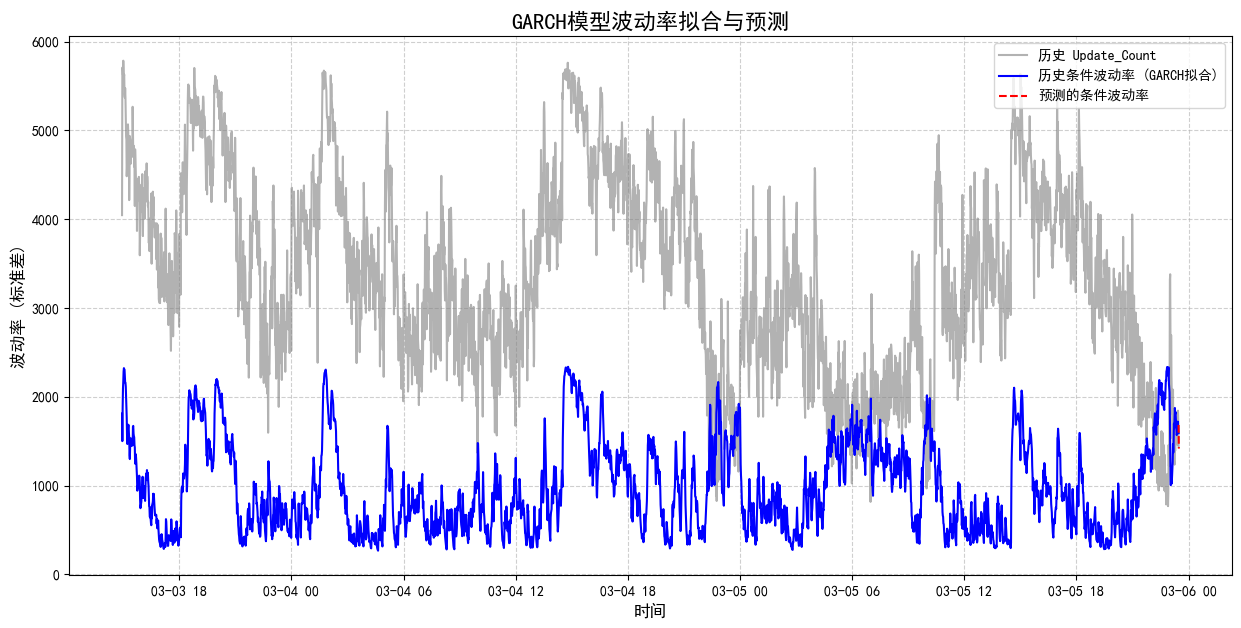

In [7]:
import numpy as np

# --- 可视化 ---
plt.figure(figsize=(15, 7))

# 绘制历史的 Update_Count
plt.plot(update_counts.index, update_counts, label='历史 Update_Count', color='gray', alpha=0.6)

# 绘制历史的条件波动率（模型拟合出的）
# results.conditional_volatility 是模型对历史数据波动率的估计
plt.plot(results.conditional_volatility.index, results.conditional_volatility, 
         label='历史条件波动率 (GARCH拟合)', color='blue')

# 创建未来的时间索引用于绘图
last_timestamp = update_counts.index[-1]
future_index = pd.date_range(start=last_timestamp, periods=51, freq='S')[1:] # 50个未来秒

# 绘制预测的波动率
plt.plot(future_index, predicted_volatility, label='预测的条件波动率', color='red', linestyle='--')

plt.title('GARCH模型波动率拟合与预测', fontsize=16)
plt.xlabel('时间', fontsize=12)
plt.ylabel('波动率 (标准差)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

d:\Software\miniconda3\envs\CryptoSpider\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.193e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\Software\miniconda3\envs\CryptoSpider\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.193e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\Software\minicond

滚动预测进度: 50/679


d:\Software\miniconda3\envs\CryptoSpider\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.175e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\Software\miniconda3\envs\CryptoSpider\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.175e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\Software\minicond

滚动预测进度: 100/679


d:\Software\miniconda3\envs\CryptoSpider\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.158e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\Software\miniconda3\envs\CryptoSpider\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.157e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\Software\minicond

...

滚动预测进度: 600/679


d:\Software\miniconda3\envs\CryptoSpider\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.12e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\Software\miniconda3\envs\CryptoSpider\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.121e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\Software\miniconda

滚动预测进度: 650/679


d:\Software\miniconda3\envs\CryptoSpider\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.173e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\Software\miniconda3\envs\CryptoSpider\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.174e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\Software\minicond

------------------------------
滚动预测的均方误差 (MSE): 170256632564205.9062


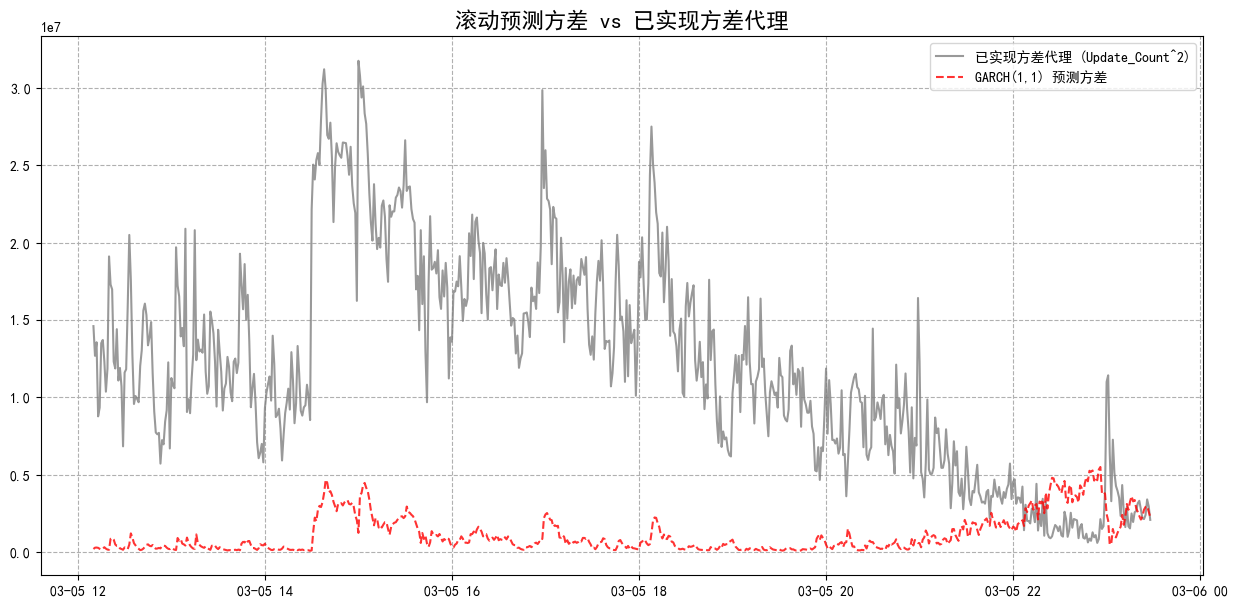

In [8]:
from sklearn.metrics import mean_squared_error

# 1. 分割数据
n_total = len(update_counts)
n_train = int(n_total * 0.8)
train_data = update_counts[:n_train]
test_data = update_counts[n_train:]

# 2. 滚动预测
predictions = []
test_size = len(test_data)

for i in range(test_size):
    # 定义当前的训练数据
    current_train_data = update_counts[:n_train + i]
    
    # 训练模型
    model = arch_model(current_train_data, vol='Garch', p=1, q=1)
    # 使用上一次的参数作为起点，可以加速收敛
    res = model.fit(disp='off', last_obs=current_train_data.index[-1])
    
    # 向前预测一步
    forecast = res.forecast(horizon=1, reindex=False)
    
    # 存储预测的方差
    pred_variance = forecast.variance.iloc[-1, 0]
    predictions.append(pred_variance)
    
    # 打印进度
    if (i+1) % 50 == 0:
        print(f"滚动预测进度: {i+1}/{test_size}")

# 3. 评估
# 将预测列表转为Pandas Series，方便对齐索引
predicted_variances = pd.Series(predictions, index=test_data.index)

# 计算已实现方差的代理 (真实值的平方)
realized_variances_proxy = test_data**2

# 计算MSE
mse = mean_squared_error(realized_variances_proxy, predicted_variances)

print("-" * 30)
print(f"滚动预测的均方误差 (MSE): {mse:.4f}")

# 可视化对比
plt.figure(figsize=(15, 7))
plt.plot(realized_variances_proxy.index, realized_variances_proxy, label='已实现方差代理 (Update_Count^2)', color='gray', alpha=0.8)
plt.plot(predicted_variances.index, predicted_variances, label='GARCH(1,1) 预测方差', color='red', linestyle='--', alpha=0.8)
plt.title('滚动预测方差 vs 已实现方差代理', fontsize=16)
plt.legend()
plt.grid(True, linestyle='--')
plt.show()